## Check Mistral OCR + pixtral-12b-latest

In [2]:
from mistral_client import MistralFormExtractor

In [3]:
IMAGE_PATH = "../../samples/input/jml.png"

# # View Image
# from PIL import Image
# Image.open(IMAGE_PATH)

# View OCR Result
mistral_extractor = MistralFormExtractor()
parsed_form, ocr_text = mistral_extractor.structured_ocr(IMAGE_PATH)
print(parsed_form)

✅ Mistral client initialized
Running Mistral OCR...
Parsing with Mistral LLM...
Upload_ID='AJ-20251113-152907-6006f778' Extracted_AT='2025-11-13T15:29:07.930827' Aircraft_Model='Airbus A320' Registration_Number='9M-XX1' Departure_Airport='KUL' Arrival_Airport='SIN' Crew=4 Fuel='12k' Load=150 Defect_Message='WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'


In [4]:
import json
from typing import Dict, Any, List, Optional, Tuple

# convert AircraftJourneyFormExtractor output to json model
parsed_form = parsed_form.model_dump_json(indent=2)
print(parsed_form)

{
  "Upload_ID": "AJ-20251113-152907-6006f778",
  "Extracted_AT": "2025-11-13T15:29:07.930827",
  "Aircraft_Model": "Airbus A320",
  "Registration_Number": "9M-XX1",
  "Departure_Airport": "KUL",
  "Arrival_Airport": "SIN",
  "Crew": 4,
  "Fuel": "12k",
  "Load": 150,
  "Defect_Message": "WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE."
}


In [5]:
# multiple json records
from glob import glob
import os

IMAGES = glob("../../samples/input/*.png")
IMAGES

['../../samples/input/jml1.png',
 '../../samples/input/jml3.png',
 '../../samples/input/jml2.png',
 '../../samples/input/jml.png']

In [6]:
IMAGES = [
    '../../samples/input/jml1.png',
    '../../samples/input/jml3.png',
    '../../samples/input/jml2.png',
    '../../samples/input/jml.png'
    ]

In [7]:
parse_results = []
for img_path in IMAGES:
    result, _ = mistral_extractor.structured_ocr(img_path)
    # print(result.model_dump_json(indent=2))
    parse_results.append(result.model_dump())  # Use model_dump() directly

# Now you can convert to DataFrame
import pandas as pd
df = pd.DataFrame(parse_results)
display(df)

Running Mistral OCR...
Parsing with Mistral LLM...
Running Mistral OCR...
Parsing with Mistral LLM...
Running Mistral OCR...
Parsing with Mistral LLM...
Running Mistral OCR...
Parsing with Mistral LLM...


,Upload_ID,Extracted_AT,Aircraft_Model,Registration_Number,Departure_Airport,Arrival_Airport,Crew,Fuel,Load,Defect_Message
0,AJ-20251113-152924-0f39b460,2025-11-13T15:29:24.663312,None,None,None,None,NaN,None,NaN,None
1,AJ-20251113-152956-b66e012f,2025-11-13T15:29:56.366923,None,None,None,None,NaN,None,NaN,None
2,AJ-20251113-152958-932c434b,2025-11-13T15:29:58.997230,None,9A-AGG,LHR,CDG,NaN,123,NaN,None
3,AJ-20251113-153003-f4982e98,2025-11-13T15:30:03.401685,Airbus A320,9M-XX1,KUL,SIN,4.0,12k,150.0,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...


In [8]:
parse_results

[{'Upload_ID': 'AJ-20251113-152924-0f39b460',
  'Extracted_AT': '2025-11-13T15:29:24.663312',
  'Aircraft_Model': None,
  'Registration_Number': None,
  'Departure_Airport': None,
  'Arrival_Airport': None,
  'Crew': None,
  'Fuel': None,
  'Load': None,
  'Defect_Message': None},
 {'Upload_ID': 'AJ-20251113-152956-b66e012f',
  'Extracted_AT': '2025-11-13T15:29:56.366923',
  'Aircraft_Model': None,
  'Registration_Number': None,
  'Departure_Airport': None,
  'Arrival_Airport': None,
  'Crew': None,
  'Fuel': None,
  'Load': None,
  'Defect_Message': None},
 {'Upload_ID': 'AJ-20251113-152958-932c434b',
  'Extracted_AT': '2025-11-13T15:29:58.997230',
  'Aircraft_Model': None,
  'Registration_Number': '9A-AGG',
  'Departure_Airport': 'LHR',
  'Arrival_Airport': 'CDG',
  'Crew': None,
  'Fuel': '123',
  'Load': None,
  'Defect_Message': None},
 {'Upload_ID': 'AJ-20251113-153003-f4982e98',
  'Extracted_AT': '2025-11-13T15:30:03.401685',
  'Aircraft_Model': 'Airbus A320',
  'Registration_Nu

In [9]:
df

,Upload_ID,Extracted_AT,Aircraft_Model,Registration_Number,Departure_Airport,Arrival_Airport,Crew,Fuel,Load,Defect_Message
0,AJ-20251113-152924-0f39b460,2025-11-13T15:29:24.663312,None,None,None,None,NaN,None,NaN,None
1,AJ-20251113-152956-b66e012f,2025-11-13T15:29:56.366923,None,None,None,None,NaN,None,NaN,None
2,AJ-20251113-152958-932c434b,2025-11-13T15:29:58.997230,None,9A-AGG,LHR,CDG,NaN,123,NaN,None
3,AJ-20251113-153003-f4982e98,2025-11-13T15:30:03.401685,Airbus A320,9M-XX1,KUL,SIN,4.0,12k,150.0,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...


In [10]:
result.model_dump()

{'Upload_ID': 'AJ-20251113-153003-f4982e98',
 'Extracted_AT': '2025-11-13T15:30:03.401685',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'}

## Check json upload to S3

In [11]:
EXTRACTED_PREFIX = "ocr_results/extracted"
EDITED_PREFIX = "ocr_results/edited"
RESULTS_PREFIX = "ocr_results/results"
UPLOAD_PREFIX = "uploads"

In [12]:
IMAGE_PATH

'../../samples/input/jml.png'

In [13]:
# @app.post("/extract/")
# create json file upload function to S3
file_path = IMAGE_PATH

# Run extraction
print("🔍 Running OCR extraction...")
result, _ = mistral_extractor.structured_ocr(str(file_path))

# Convert to dict
result_dict = json.loads(result.json())
result_dict

🔍 Running OCR extraction...
Running Mistral OCR...
Parsing with Mistral LLM...


/var/folders/yz/01283wk557g3r_2q2cbpz5dr0000gn/T/ipykernel_8768/497420407.py:10: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result_dict = json.loads(result.json())


{'Upload_ID': 'AJ-20251113-153009-56ab04c4',
 'Extracted_AT': '2025-11-13T15:30:09.130996',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'}

In [14]:
result.model_dump()

{'Upload_ID': 'AJ-20251113-153009-56ab04c4',
 'Extracted_AT': '2025-11-13T15:30:09.130996',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'}

In [32]:
df.to_csv("ocr_results.csv", index=False)

In [15]:
from aws_utils import upload_json_to_s3_folder

# @app.post("/save-extracted/")
data = result.model_dump() # convert class type to dict
upload_id = data.get("Upload_ID", "unknown")
version = data.get("version", "extracted")

print(f"Upload ID: {upload_id}, Version: {version}")
output_filename = f"{upload_id}_extracted.json"

s3_uri = None
try:
    s3_key = f"{EXTRACTED_PREFIX}/{upload_id}.json"
    print(f"☁️ Uploading to S3: {s3_key}")
    s3_uri = upload_json_to_s3_folder(json.dumps(data), s3_key=s3_key)
    print(f"✅ S3 upload successful: {s3_uri}")
except Exception as s3_error:
    print(f"⚠️ S3 upload failed (non-critical): {s3_error}")
    s3_uri = f"S3 upload failed: {str(s3_error)}"
    # pass

/Users/jusnaini/Documents/MyProject/PERSONAL/ADE_interview/libenv/lib/python3.9/site-packages/boto3/compat.py:84: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Upload ID: AJ-20251113-153009-56ab04c4, Version: extracted
☁️ Uploading to S3: ocr_results/extracted/AJ-20251113-153009-56ab04c4.json
✅ S3 upload successful: s3://aircraftform-extractor-bucket/ocr_results/extracted/AJ-20251113-153009-56ab04c4.json


In [16]:
res_json_dump = result.model_dump()
display(type(res_json_dump))

json.dumps(res_json_dump)

dict

'{"Upload_ID": "AJ-20251113-153009-56ab04c4", "Extracted_AT": "2025-11-13T15:30:09.130996", "Aircraft_Model": "Airbus A320", "Registration_Number": "9M-XX1", "Departure_Airport": "KUL", "Arrival_Airport": "SIN", "Crew": 4, "Fuel": "12k", "Load": 150, "Defect_Message": "WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE."}'

In [17]:
type(json.dumps(res_json_dump))

str

In [18]:
res_json_load = json.loads(result.json())
display(type(res_json_load))

json.dumps(res_json_load)

/var/folders/yz/01283wk557g3r_2q2cbpz5dr0000gn/T/ipykernel_8768/674909493.py:1: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  res_json_load = json.loads(result.json())


dict

'{"Upload_ID": "AJ-20251113-153009-56ab04c4", "Extracted_AT": "2025-11-13T15:30:09.130996", "Aircraft_Model": "Airbus A320", "Registration_Number": "9M-XX1", "Departure_Airport": "KUL", "Arrival_Airport": "SIN", "Crew": 4, "Fuel": "12k", "Load": 150, "Defect_Message": "WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE."}'

In [19]:
pd.DataFrame([res_json_load])

,Upload_ID,Extracted_AT,Aircraft_Model,Registration_Number,Departure_Airport,Arrival_Airport,Crew,Fuel,Load,Defect_Message
0,AJ-20251113-153009-56ab04c4,2025-11-13T15:30:09.130996,Airbus A320,9M-XX1,KUL,SIN,4,12k,150,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...


## Check OCR performance metrics

In [20]:
data

{'Upload_ID': 'AJ-20251113-153009-56ab04c4',
 'Extracted_AT': '2025-11-13T15:30:09.130996',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'}

In [21]:
from ocr_metrics import calculate_ocr_metrics

ocr_output = {'Upload_ID': 'AJ-20251113-140335-f9756256',
 'Extracted_AT': '2025-11-13T14:03:35.221558',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'
 }

ground_truth= {'Upload_ID': 'AJ-20251113-140335-f9756256',
 'Extracted_AT': '2025-11-13T14:03:35.221558',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12000',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'
 }


In [22]:
ocr_metrics_result = calculate_ocr_metrics(ocr_output, ground_truth)
ocr_metrics_result

[{'Upload_ID': 'AJ-20251113-140335-f9756256',
  'Field': 'Aircraft_Model',
  'Ground_Truth': 'Airbus A320',
  'OCR_Output': 'Airbus A320',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 {'Upload_ID': 'AJ-20251113-140335-f9756256',
  'Field': 'Registration_Number',
  'Ground_Truth': '9M-XX1',
  'OCR_Output': '9M-XX1',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 {'Upload_ID': 'AJ-20251113-140335-f9756256',
  'Field': 'Departure_Airport',
  'Ground_Truth': 'KUL',
  'OCR_Output': 'KUL',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 {'Upload_ID': 'AJ-20251113-140335-f9756256',
  'Field': 'Arrival_Airport',
  'Ground_Truth': 'SIN',
  'OCR_Output': 'SIN',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 {'Upload_ID': 'AJ-20251113-140335-f9756256',
  'Field': 'Crew',
  'Ground_Truth': '4',
  'OCR_Output': '4',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 {'Upload_ID': 'AJ-20251113-14033

In [23]:
display(type(ocr_metrics_result))

list

result [class] -> results.model_dump() [dict] ->  json.dumps(result)[str]

In [24]:
# Can convert list to DataFrame directly -> but cannot be queried easily if saved as json, but CSV is OK
pd.DataFrame(ocr_metrics_result)

,Upload_ID,Field,Ground_Truth,OCR_Output,Correct,Levenshtein,CER,WER
0,AJ-20251113-140335-f9756256,Aircraft_Model,Airbus A320,Airbus A320,1.0,0,0.0,0.0
1,AJ-20251113-140335-f9756256,Registration_Number,9M-XX1,9M-XX1,1.0,0,0.0,0.0
2,AJ-20251113-140335-f9756256,Departure_Airport,KUL,KUL,1.0,0,0.0,0.0
3,AJ-20251113-140335-f9756256,Arrival_Airport,SIN,SIN,1.0,0,0.0,0.0
4,AJ-20251113-140335-f9756256,Crew,4,4,1.0,0,0.0,0.0
5,AJ-20251113-140335-f9756256,Fuel,12000,12k,0.0,3,0.6,1.0
6,AJ-20251113-140335-f9756256,Load,150,150,1.0,0,0.0,0.0
7,AJ-20251113-140335-f9756256,Defect_Message,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...,1.0,0,0.0,0.0


In [25]:
# convert list to json string [{}] -> cannot convert list to DataFrame directly
json.dumps(ocr_metrics_result)

'[{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Aircraft_Model", "Ground_Truth": "Airbus A320", "OCR_Output": "Airbus A320", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}, {"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Registration_Number", "Ground_Truth": "9M-XX1", "OCR_Output": "9M-XX1", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}, {"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Departure_Airport", "Ground_Truth": "KUL", "OCR_Output": "KUL", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}, {"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Arrival_Airport", "Ground_Truth": "SIN", "OCR_Output": "SIN", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}, {"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Crew", "Ground_Truth": "4", "OCR_Output": "4", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}, {"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Fuel", "Ground_Truth": "12000", "OCR_Output": "12k"

In [26]:
all_results = []
for ocr, gt in [(ocr_output, ground_truth)]:  # Add more pairs here
    all_results.extend(calculate_ocr_metrics(ocr, gt))

In [ ]:
# convert from list dict to JSON string {}
# For result to be queried easily, save as CSV/PARQUET, JSON will require SerDE transformation
all_results


In [94]:
"\n\n".join(json.dumps(data) for data in ocr_metrics_result) 

'{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Aircraft_Model", "Ground_Truth": "Airbus A320", "OCR_Output": "Airbus A320", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}\n\n{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Registration_Number", "Ground_Truth": "9M-XX1", "OCR_Output": "9M-XX1", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}\n\n{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Departure_Airport", "Ground_Truth": "KUL", "OCR_Output": "KUL", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}\n\n{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Arrival_Airport", "Ground_Truth": "SIN", "OCR_Output": "SIN", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}\n\n{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Crew", "Ground_Truth": "4", "OCR_Output": "4", "Correct": 1.0, "Levenshtein": 0, "CER": 0.0, "WER": 0.0}\n\n{"Upload_ID": "AJ-20251113-140335-f9756256", "Field": "Fuel", "Ground_Truth": "12000", "OCR_Outpu

In [ ]:
# Convert DataFrame to CSV string in memory
csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False) # Set index=False to exclude the DataFrame index

# Create an S3 client
s3_client = boto3.client('s3')

# Upload the CSV string to S3
s3_client.put_object(Bucket=bucket_name, Key=s3_object_key, Body=csv_buffer.getvalue())

In [30]:

pd.DataFrame(ocr_metrics_result).Upload_ID.unique()

array(['AJ-20251113-140335-f9756256'], dtype=object)

In [31]:
from aws_utils import upload_dataframe_to_s3_folder

upload_dataframe_to_s3_folder(pd.DataFrame(ocr_metrics_result), folder_prefix=RESULTS_PREFIX, filename=f"AJ-20251113-140335-f9756256.csv")

/Users/jusnaini/Documents/MyProject/PERSONAL/ADE_interview/libenv/lib/python3.9/site-packages/boto3/compat.py:84: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


's3://aircraftform-extractor-bucket/ocr_metrics/resultsAJ-20251113-140335-f9756256.csv'

In [95]:
from io import StringIO
csv_buffer = StringIO()
df_result = pd.DataFrame(ocr_metrics_result)
df_result.(csv_buffer, index=False) 
s3_client.put_object(Bucket=bucket_name, Key=s3_object_key, Body=csv_buffer.getvalue())

,Upload_ID,Field,Ground_Truth,OCR_Output,Correct,Levenshtein,CER,WER
0,AJ-20251113-140335-f9756256,Aircraft_Model,Airbus A320,Airbus A320,1.0,0,0.0,0.0
1,AJ-20251113-140335-f9756256,Registration_Number,9M-XX1,9M-XX1,1.0,0,0.0,0.0
2,AJ-20251113-140335-f9756256,Departure_Airport,KUL,KUL,1.0,0,0.0,0.0
3,AJ-20251113-140335-f9756256,Arrival_Airport,SIN,SIN,1.0,0,0.0,0.0
4,AJ-20251113-140335-f9756256,Crew,4,4,1.0,0,0.0,0.0
5,AJ-20251113-140335-f9756256,Fuel,12000,12k,0.0,3,0.6,1.0
6,AJ-20251113-140335-f9756256,Load,150,150,1.0,0,0.0,0.0
7,AJ-20251113-140335-f9756256,Defect_Message,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...,WAT POWL DS 244161 AND DS 244162 AL USS THAN C...,1.0,0,0.0,0.0


## Add validator

In [12]:
ocr_input = {
  "Upload_ID": "AJ-20251113-161655-360c99fc",
  "Extracted_AT": "2025-11-13T16:16:55.492621",
  "Aircraft_Model": "Airbus A320",
  "Registration_Number": "9M-XX1",
  "Departure_Airport": "KUL",
  "Arrival_Airport": "SIN",
  "Crew": 4,
  "Fuel": "12k",
  "Load": 150,
  "Defect_Message": "WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.",
  "version": "extracted",
  "saved_at": "2025-11-13T16:17:09.654166",
  "file_name": "jml.png"
}


img_path = '../../samples/input/jml.png'

✅ Mistral client initialized


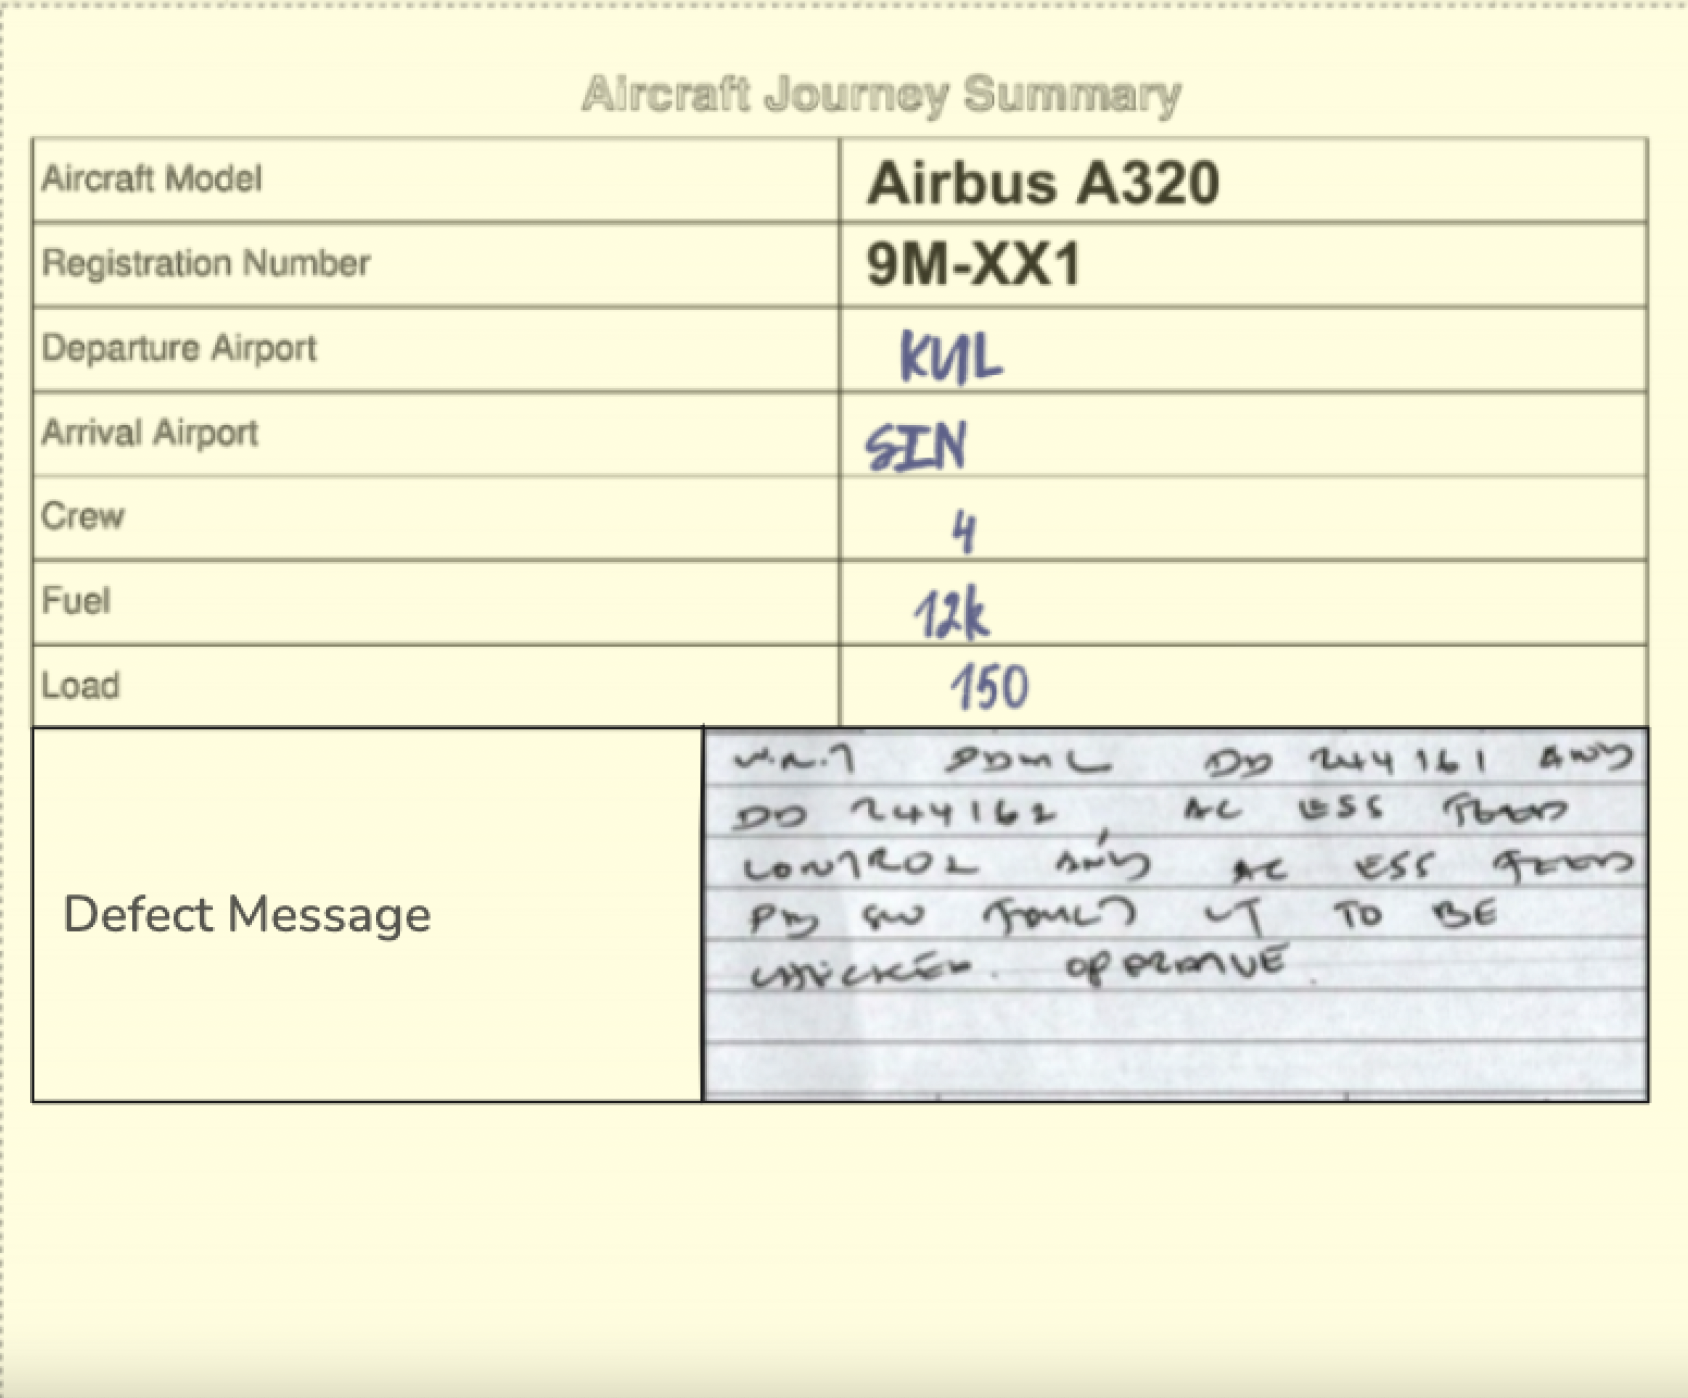

In [4]:
from mistral_client import MistralFormExtractor
from PIL import Image

extractor = MistralFormExtractor()
Image.open(img_path)

In [5]:
parsed_form,ocr_text_markdown = extractor.structured_ocr(img_path)

Running Mistral OCR...
Parsing with Mistral LLM...


In [8]:
display(parsed_form)
display(ocr_text_markdown)

AircraftJourneyForm(Upload_ID='AJ-20251114-120105-377561da', Extracted_AT='2025-11-14T12:01:05.350440', Aircraft_Model='Airbus A320', Registration_Number='9M-XX1', Departure_Airport='KUL', Arrival_Airport='SIN', Crew=4, Fuel='12k', Load=150, Defect_Message='VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25')

'# Aircraft Journey Summary\n\n|  Aircraft Model | Airbus A320  |\n| --- | --- |\n|  Registration Number | 9M-XX1  |\n|  Departure Airport | KML  |\n|  Arrival Airport | SIN  |\n|  Crew | 4  |\n|  Fuel | 12k  |\n|  Load | 150  |\n\nDefect Message\n\n|  VAN | POHL | DO  |\n| --- | --- | --- |\n|  244161 | 244161 | 244162  |\n|  255 | 255 | 255  |\n|  25 | 25 | 255  |\n|  25 | 25 | 25  |\n|  25 | 25 | 25  |\n|  25 | 25 | 25  |\n|  25 | 25 | 25  |\n\n![img-0.jpeg](img-0.jpeg)'

In [6]:
# Convert AircraftJourneyForm type to dict
a = dict(parsed_form)
b = parsed_form.model_dump()

In [19]:
parsed_form.Registration_Number

'9M-XX1'

In [ ]:
from validator import FieldValidator

field_validator = FieldValidator()
fields = ['Aircraft_Model', 'Registration_Number', 'Departure_Airport', 'Arrival_Airport', 'Crew', 'Fuel', 'Load', 'Defect_Message']

# data_validation = []
# for k,v in ocr_input.items():
#     print (k,v)
#     f
check_aircraft_model = field_validator.validate_aircraft_model(parsed_form.Aircraft_Model,ocr_text_markdown)
check_airport = field_validator.validate_aircraft_model(parsed_form.Arrival_Airport,ocr_text_markdown)
check_aircraft_model = field_validator.validate_aircraft_model(a['Aircraft_Model'],ocr_text_markdown)
check_aircraft_model = field_validator.validate_aircraft_model(a['Aircraft_Model'],ocr_text_markdown)
check_aircraft_model = field_validator.validate_aircraft_model(a['Aircraft_Model'],ocr_text_markdown)
check_aircraft_model 

FieldExtraction(value='Airbus A320', confidence=1.0, validated=True, validation_method='known_model', reason=None)

In [18]:
dir(field_validator)
['_estimate_confidence',
 'validate_aircraft_model',
 'validate_airport',
 'validate_all_fields',
 'validate_defect_message',
 'validate_fuel',
 'validate_numeric',
 'validate_registration']

['_estimate_confidence',
 'validate_aircraft_model',
 'validate_airport',
 'validate_all_fields',
 'validate_defect_message',
 'validate_fuel',
 'validate_numeric',
 'validate_registration']

#### Steps:

In [ ]:
# Step 1: Extract with Mistral
parsed_form, ocr_text_markdown = extractor.structured_ocr(img_path)

print("\nValidating extracted fields...")

In [ ]:
# Step 2: Validate each field
registration = field_validator.validate_registration(parsed_form.Registration_Number)
aircraft_model = field_validator.validate_aircraft_model(parsed_form.Aircraft_Model, ocr_text_markdown)
departure = field_validator.validate_airport(parsed_form.Departure_Airport, "departure")
arrival = field_validator.validate_airport(parsed_form.Arrival_Airport, "arrival")
crew = field_validator.validate_numeric(parsed_form.Crew, "crew", min_val=2, max_val=20, ocr_text=ocr_text_markdown)
load = field_validator.validate_numeric(parsed_form.Load, "load", min_val=0, max_val=500, ocr_text=ocr_text_markdown)
fuel = field_validator.validate_fuel(parsed_form.Fuel, ocr_text_markdown)
defect_message = field_validator.validate_defect_message(parsed_form.Defect_Message, ocr_text_markdown)

In [148]:
parsed_form.model_dump()

{'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [149]:
# Step 3: Build structured result == validate_all_fields
from dataclasses import dataclass, asdict
data = {
    'Aircraft_Model': asdict(aircraft_model),
    'Registration_Number': asdict(registration),
    'Departure_Airport': asdict(departure),
    'Arrival_Airport': asdict(arrival),
    'Crew': asdict(crew),
    'Fuel': asdict(fuel),
    'Load': asdict(load),
    'Defect_Message': asdict(defect_message)
        }
data

{'Aircraft_Model': {'value': 'Airbus A320',
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'known_model',
  'reason': None},
 'Registration_Number': {'value': '9M-XX1',
  'confidence': 0.9,
  'validated': True,
  'validation_method': 'regex_pattern',
  'reason': None},
 'Departure_Airport': {'value': 'KUL',
  'confidence': 0.95,
  'validated': True,
  'validation_method': 'iata_validation',
  'reason': None},
 'Arrival_Airport': {'value': 'SIN',
  'confidence': 0.95,
  'validated': True,
  'validation_method': 'iata_validation',
  'reason': None},
 'Crew': {'value': 4,
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'range_check_2_20',
  'reason': None},
 'Fuel': {'value': '12k',
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'contains_numeric',
  'reason': None},
 'Load': {'value': 150,
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'range_check_0_500',
  'reason': None},
 'Defect_Message': {'value': 'VAN POHL DO 2

In [25]:
# Step 4: Calculate overall metrics
confidences = [f['confidence'] for f in data.values() if f['value'] is not None]
fields_validated = sum(1 for f in data.values() if f['validated'])
flagged_fields = [ name for name, field in data.items() if field['value'] is not None and field['confidence'] < 0.7]

In [27]:
# Step 5: Build final result
result = {
    'upload_id': parsed_form.Upload_ID,
    'extracted_at': parsed_form.Extracted_AT,
    'extraction_method': 'mistral-ocr-latest + pixtral-12b',
    
    'data': data,
    
    'metadata': {
        'overall_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
        'fields_extracted': sum(1 for f in data.values() if f['value'] is not None),
        'fields_validated': fields_validated,
        'requires_human_review': len(flagged_fields) > 0 or len(confidences) == 0,
        'flagged_fields': flagged_fields,
        'total_fields': len(data)
    },
    
    'raw_ocr_markdown': ocr_text_markdown  # For debugging
}

result

{'upload_id': 'AJ-20251114-120105-377561da',
 'extracted_at': '2025-11-14T12:01:05.350440',
 'extraction_method': 'mistral-ocr-latest + pixtral-12b',
 'data': {'aircraft_model': {'value': 'Airbus A320',
   'confidence': 1.0,
   'validated': True,
   'validation_method': 'known_model',
   'reason': None},
  'registration': {'value': '9M-XX1',
   'confidence': 0.9,
   'validated': True,
   'validation_method': 'regex_pattern',
   'reason': None},
  'departure_airport': {'value': 'KUL',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'arrival_airport': {'value': 'SIN',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'crew': {'value': 4,
   'confidence': 1.0,
   'validated': True,
   'validation_method': 'range_check_2_20',
   'reason': None},
  'load': {'value': 150,
   'confidence': 1.0,
   'validated': True,
   'validation_method': 'range_check_0_500',
   'reason':

In [55]:
# Print detailed analysis
print("\n📊 Extraction Analysis:")
print(f"  Overall Confidence: {result['metadata']['overall_confidence']:.2%}")
print(f"  Fields Extracted: {result['metadata']['fields_extracted']}/8")
print(f"  Fields Validated: {result['metadata']['fields_validated']}")
print(f"  Requires Review: {result['metadata']['requires_human_review']}")


📊 Extraction Analysis:
  Overall Confidence: 90.25%
  Fields Extracted: 8/8
  Fields Validated: 7
  Requires Review: True


#### Using validate_all_fields

In [89]:
# validate all fields
data_all = field_validator.validate_all_fields(parsed_form,ocr_text_markdown)
data_all

{'aircraft_model': FieldExtraction(value='Airbus A320', confidence=1.0, validated=True, validation_method='known_model', reason=None),
 'registration': FieldExtraction(value='9M-XX1', confidence=0.9, validated=True, validation_method='regex_pattern', reason=None),
 'departure_airport': FieldExtraction(value='KUL', confidence=0.95, validated=True, validation_method='iata_validation', reason=None),
 'arrival_airport': FieldExtraction(value='SIN', confidence=0.95, validated=True, validation_method='iata_validation', reason=None),
 'crew': FieldExtraction(value=4, confidence=1.0, validated=True, validation_method='range_check_2_20', reason=None),
 'load': FieldExtraction(value=150, confidence=1.0, validated=True, validation_method='range_check_0_500', reason=None),
 'fuel': FieldExtraction(value='12k', confidence=1.0, validated=True, validation_method='contains_numeric', reason=None),
 'defect_message': FieldExtraction(value='VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 2

In [90]:
{k: v.value for k, v in data_all.items()}

{'aircraft_model': 'Airbus A320',
 'registration': '9M-XX1',
 'departure_airport': 'KUL',
 'arrival_airport': 'SIN',
 'crew': 4,
 'load': 150,
 'fuel': '12k',
 'defect_message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [92]:
full_data = {
    k: {
        'value': v.value,
        'confidence': v.confidence,
        'validated': v.validated,
        'validation_method': v.validation_method,
        'reason': v.reason
    } for k, v in data_all.items()
}
full_data

{'aircraft_model': {'value': 'Airbus A320',
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'known_model',
  'reason': None},
 'registration': {'value': '9M-XX1',
  'confidence': 0.9,
  'validated': True,
  'validation_method': 'regex_pattern',
  'reason': None},
 'departure_airport': {'value': 'KUL',
  'confidence': 0.95,
  'validated': True,
  'validation_method': 'iata_validation',
  'reason': None},
 'arrival_airport': {'value': 'SIN',
  'confidence': 0.95,
  'validated': True,
  'validation_method': 'iata_validation',
  'reason': None},
 'crew': {'value': 4,
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'range_check_2_20',
  'reason': None},
 'load': {'value': 150,
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'range_check_0_500',
  'reason': None},
 'fuel': {'value': '12k',
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'contains_numeric',
  'reason': None},
 'defect_message': {'value': 'VAN POHL DO 244161 2

In [73]:
combined_all = {
    'extracted_data' :parsed_form.model_dump(),
    'data_validation': data,
    'metadata': {
        'overall_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
        'fields_extracted': sum(1 for f in data.values() if f['value'] is not None),
        'fields_validated': fields_validated,
        'requires_human_review': len(flagged_fields) > 0 or len(confidences) == 0,
        'flagged_fields': flagged_fields,
        'total_fields': len(data)
    },
    
    'raw_ocr_markdown': ocr_text_markdown  # For debugging
}


In [85]:
combined_all

{'extracted_data': {'Upload_ID': 'AJ-20251114-120105-377561da',
  'Extracted_AT': '2025-11-14T12:01:05.350440',
  'Aircraft_Model': 'Airbus A320',
  'Registration_Number': '9M-XX1',
  'Departure_Airport': 'KUL',
  'Arrival_Airport': 'SIN',
  'Crew': 4,
  'Fuel': '12k',
  'Load': 150,
  'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'},
 'data_validation': {'aircraft_model': {'value': 'Airbus A320',
   'confidence': 1.0,
   'validated': True,
   'validation_method': 'known_model',
   'reason': None},
  'registration': {'value': '9M-XX1',
   'confidence': 0.9,
   'validated': True,
   'validation_method': 'regex_pattern',
   'reason': None},
  'departure_airport': {'value': 'KUL',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'arrival_airport': {'value': 'SIN',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'crew': {'val

In [87]:
# TEST SEND OUT
from aws_utils import upload_json_to_s3_folder

upload_json_to_s3_folder(json.dumps(combined_all),s3_key='test.json')

/Users/jusnaini/Documents/MyProject/PERSONAL/ADE_interview/libenv/lib/python3.9/site-packages/boto3/compat.py:84: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


's3://aircraftform-extractor-bucket/test.json'

In [84]:
json.dumps(combined_all)

'{"extracted_data": {"Upload_ID": "AJ-20251114-120105-377561da", "Extracted_AT": "2025-11-14T12:01:05.350440", "Aircraft_Model": "Airbus A320", "Registration_Number": "9M-XX1", "Departure_Airport": "KUL", "Arrival_Airport": "SIN", "Crew": 4, "Fuel": "12k", "Load": 150, "Defect_Message": "VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25"}, "data_validation": {"aircraft_model": {"value": "Airbus A320", "confidence": 1.0, "validated": true, "validation_method": "known_model", "reason": null}, "registration": {"value": "9M-XX1", "confidence": 0.9, "validated": true, "validation_method": "regex_pattern", "reason": null}, "departure_airport": {"value": "KUL", "confidence": 0.95, "validated": true, "validation_method": "iata_validation", "reason": null}, "arrival_airport": {"value": "SIN", "confidence": 0.95, "validated": true, "validation_method": "iata_validation", "reason": null}, "crew": {"value": 4, "confidence": 1.0, "validated": true, "validation_method": "range_

In [80]:
combined_all['metadata']

{'overall_confidence': 0.9025,
 'fields_extracted': 8,
 'fields_validated': 7,
 'requires_human_review': True,
 'flagged_fields': ['defect_message'],
 'total_fields': 8}

In [74]:
pd.DataFrame(combined_all)

,extracted_data,data_validation,metadata,raw_ocr_markdown
Upload_ID,AJ-20251114-120105-377561da,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Extracted_AT,2025-11-14T12:01:05.350440,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Aircraft_Model,Airbus A320,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Registration_Number,9M-XX1,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Departure_Airport,KUL,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Arrival_Airport,SIN,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Crew,4,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Fuel,12k,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Load,150,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
Defect_Message,VAN POHL DO 244161 244161 244162 255 255 255 2...,NaN,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...


In [61]:
# print scalar dict
import pandas as pd
pd.DataFrame([dict(data_all)])

# df = pd.DataFrame([dict(parsed_form)])

,aircraft_model,registration,departure_airport,arrival_airport,crew,load,fuel,defect_message
0,"FieldExtraction(value='Airbus A320', confidenc...","FieldExtraction(value='9M-XX1', confidence=0.9...","FieldExtraction(value='KUL', confidence=0.95, ...","FieldExtraction(value='SIN', confidence=0.95, ...","FieldExtraction(value=4, confidence=1.0, valid...","FieldExtraction(value=150, confidence=1.0, val...","FieldExtraction(value='12k', confidence=1.0, v...",FieldExtraction(value='VAN POHL DO 244161 2441...


In [33]:
parsed_form.model_dump()

{'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [34]:
dict(parsed_form)

{'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [41]:
result2 = {
    'data': data,
    
    'metadata': {
        'overall_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
        'fields_extracted': sum(1 for f in data.values() if f['value'] is not None),
        'fields_validated': fields_validated,
        'requires_human_review': len(flagged_fields) > 0 or len(confidences) == 0,
        'flagged_fields': flagged_fields,
        'total_fields': len(data)
    },
    
    'raw_ocr_markdown': ocr_text_markdown  # For debugging
}

In [40]:
import pandas as pd
pd.DataFrame(result)

,upload_id,extracted_at,extraction_method,data,metadata,raw_ocr_markdown
aircraft_model,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': 'Airbus A320', 'confidence': 1.0, 'v...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
registration,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': '9M-XX1', 'confidence': 0.9, 'valida...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
departure_airport,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': 'KUL', 'confidence': 0.95, 'validate...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
arrival_airport,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': 'SIN', 'confidence': 0.95, 'validate...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
crew,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': 4, 'confidence': 1.0, 'validated': T...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
load,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': 150, 'confidence': 1.0, 'validated':...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
fuel,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,"{'value': '12k', 'confidence': 1.0, 'validated...",NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
defect_message,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,{'value': 'VAN POHL DO 244161 244161 244162 25...,NaN,# Aircraft Journey Summary\n\n| Aircraft Mode...
overall_confidence,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,NaN,0.9025,# Aircraft Journey Summary\n\n| Aircraft Mode...
fields_extracted,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,mistral-ocr-latest + pixtral-12b,NaN,8,# Aircraft Journey Summary\n\n| Aircraft Mode...


In [46]:
parsed_form.model_dump()

{'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [47]:
pd.DataFrame(data)

,aircraft_model,registration,departure_airport,arrival_airport,crew,load,fuel,defect_message
value,Airbus A320,9M-XX1,KUL,SIN,4,150,12k,VAN POHL DO 244161 244161 244162 255 255 255 2...
confidence,1.0,0.9,0.95,0.95,1.0,1.0,1.0,0.42
validated,True,True,True,True,True,True,True,False
validation_method,known_model,regex_pattern,iata_validation,iata_validation,range_check_2_20,range_check_0_500,contains_numeric,None
reason,None,None,None,None,None,None,None,freetext_low_confidence


In [ ]:
parsed_form.model_dump() # scalar value

{'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [ ]:
# to convert scalar dict to dataframa
df = pd.DataFrame([dict(parsed_form)])
display(df)

df = pd.DataFrame.from_dict(dict(parsed_form), orient='index', columns=['Value'])
display(df)

,Upload_ID,Extracted_AT,Aircraft_Model,Registration_Number,Departure_Airport,Arrival_Airport,Crew,Fuel,Load,Defect_Message
0,AJ-20251114-120105-377561da,2025-11-14T12:01:05.350440,Airbus A320,9M-XX1,KUL,SIN,4,12k,150,VAN POHL DO 244161 244161 244162 255 255 255 2...


,Value
Upload_ID,AJ-20251114-120105-377561da
Extracted_AT,2025-11-14T12:01:05.350440
Aircraft_Model,Airbus A320
Registration_Number,9M-XX1
Departure_Airport,KUL
Arrival_Airport,SIN
Crew,4
Fuel,12k
Load,150
Defect_Message,VAN POHL DO 244161 244161 244162 255 255 255 2...


## Metrics

In [1]:
import ocr_metrics

extracted = {'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

edited = {'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [96]:
import ocr_metrics

In [97]:
dir(ocr_metrics)

['Any',
 'Dict',
 'List',
 'StringIO',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'boto3',
 'calculate_ocr_metrics',
 'char_error_rate',
 'compute_accuracy',
 'csv',
 'distance',
 'jiwer',
 'os',
 'word_error_rate']

In [105]:
Upload_ID = extracted.get('Upload_ID')
Upload_ID

'AJ-20251114-120105-377561da'

In [106]:
extracted.keys()

dict_keys(['Upload_ID', 'Extracted_AT', 'Aircraft_Model', 'Registration_Number', 'Departure_Airport', 'Arrival_Airport', 'Crew', 'Fuel', 'Load', 'Defect_Message'])

In [9]:
AIRCRAFT_FIELDS = [
    'Aircraft_Model', 
    'Registration_Number', 
    'Departure_Airport', 
    'Arrival_Airport', 
    'Crew', 'Fuel', 'Load', 'Defect_Message']

In [10]:
Upload_ID = extracted.get('Upload_ID')
#
#  Initialize the result dictionary with Upload_ID
result = {
    'Upload_ID': Upload_ID
}

# Add each field as a separate key in the result dictionary
for key in AIRCRAFT_FIELDS:
    gt_val = str(edited.get(key, "") or "")
    ocr_val = str(extracted.get(key, "") or "")
    
    result[key] = {
        "Ground_Truth": gt_val,
        "OCR_Output": ocr_val,
        "Correct": ocr_metrics.compute_accuracy(gt_val, ocr_val),
        "Levenshtein": ocr_metrics.distance(gt_val, ocr_val),
        "CER": round(ocr_metrics.char_error_rate(gt_val, ocr_val), 4),
        "WER": round(ocr_metrics.word_error_rate(gt_val, ocr_val), 4),
    }

print(result)


{'Upload_ID': 'AJ-20251114-120105-377561da', 'Aircraft_Model': {'Ground_Truth': 'Airbus A320', 'OCR_Output': 'Airbus A320', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Registration_Number': {'Ground_Truth': '9M-XX1', 'OCR_Output': '9M-XX1', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Departure_Airport': {'Ground_Truth': 'KUL', 'OCR_Output': 'KUL', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Arrival_Airport': {'Ground_Truth': 'SIN', 'OCR_Output': 'SIN', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Crew': {'Ground_Truth': '4', 'OCR_Output': '4', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Fuel': {'Ground_Truth': '12k', 'OCR_Output': '12k', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Load': {'Ground_Truth': '150', 'OCR_Output': '150', 'Correct': 1.0, 'Levenshtein': 0, 'CER': 0.0, 'WER': 0.0}, 'Defect_Message': {'Ground_Truth': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25

In [11]:
result

{'Upload_ID': 'AJ-20251114-120105-377561da',
 'Aircraft_Model': {'Ground_Truth': 'Airbus A320',
  'OCR_Output': 'Airbus A320',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Registration_Number': {'Ground_Truth': '9M-XX1',
  'OCR_Output': '9M-XX1',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Departure_Airport': {'Ground_Truth': 'KUL',
  'OCR_Output': 'KUL',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Arrival_Airport': {'Ground_Truth': 'SIN',
  'OCR_Output': 'SIN',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Crew': {'Ground_Truth': '4',
  'OCR_Output': '4',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Fuel': {'Ground_Truth': '12k',
  'OCR_Output': '12k',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Load': {'Ground_Truth': '150',
  'OCR_Output': '150',
  'Correct': 1.0,
  'Levenshtein': 0,
  'CER': 0.0,
  'WER': 0.0},
 'Defect_Message': {'Ground

In [143]:
pd.DataFrame(result)

,Upload_ID,Aircraft_Model,Registration_Number,Departure_Airport,Arrival_Airport,Crew,Fuel,Load,Defect_Message
Ground_Truth,AJ-20251114-120105-377561da,Airbus A320,9M-XX1,KUL,SIN,4,12k,150,VAN POHL DO 244161 244161 244162 255 255 255 2...
OCR_Output,AJ-20251114-120105-377561da,Airbus A320,9M-XX1,KUL,SIN,4,12k,150,VAN POHL DO 244161 244161 244162 255 255 255 2...
Correct,AJ-20251114-120105-377561da,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Levenshtein,AJ-20251114-120105-377561da,0,0,0,0,0,0,0,0
CER,AJ-20251114-120105-377561da,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WER,AJ-20251114-120105-377561da,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [153]:
data

{'Aircraft_Model': {'value': 'Airbus A320',
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'known_model',
  'reason': None},
 'Registration_Number': {'value': '9M-XX1',
  'confidence': 0.9,
  'validated': True,
  'validation_method': 'regex_pattern',
  'reason': None},
 'Departure_Airport': {'value': 'KUL',
  'confidence': 0.95,
  'validated': True,
  'validation_method': 'iata_validation',
  'reason': None},
 'Arrival_Airport': {'value': 'SIN',
  'confidence': 0.95,
  'validated': True,
  'validation_method': 'iata_validation',
  'reason': None},
 'Crew': {'value': 4,
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'range_check_2_20',
  'reason': None},
 'Fuel': {'value': '12k',
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'contains_numeric',
  'reason': None},
 'Load': {'value': 150,
  'confidence': 1.0,
  'validated': True,
  'validation_method': 'range_check_0_500',
  'reason': None},
 'Defect_Message': {'value': 'VAN POHL DO 2

In [ ]:
OCR_OUTPUT_ALL_COMBINED = {
    'extracted_data' : dict(parsed_form),
    'data_validation': data,
    'metadata': {
        'overall_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
        'fields_extracted': sum(1 for f in data.values() if f['value'] is not None),
        'fields_validated': fields_validated,
        'requires_human_review': len(flagged_fields) > 0 or len(confidences) == 0,
        'flagged_fields': flagged_fields,
        'total_fields': len(data)
    },
    'results': result
}

In [151]:
OCR_OUTPUT_ALL_COMBINED

{'extracted_data': {'Upload_ID': 'AJ-20251114-120105-377561da',
  'Extracted_AT': '2025-11-14T12:01:05.350440',
  'Aircraft_Model': 'Airbus A320',
  'Registration_Number': '9M-XX1',
  'Departure_Airport': 'KUL',
  'Arrival_Airport': 'SIN',
  'Crew': 4,
  'Fuel': '12k',
  'Load': 150,
  'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'},
 'data_validation': {'Aircraft_Model': {'value': 'Airbus A320',
   'confidence': 1.0,
   'validated': True,
   'validation_method': 'known_model',
   'reason': None},
  'Registration_Number': {'value': '9M-XX1',
   'confidence': 0.9,
   'validated': True,
   'validation_method': 'regex_pattern',
   'reason': None},
  'Departure_Airport': {'value': 'KUL',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'Arrival_Airport': {'value': 'SIN',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'Crew'

In [152]:
pd.DataFrame(OCR_OUTPUT_ALL_COMBINED)

,extracted_data,data_validation,metadata,results
Upload_ID,AJ-20251114-120105-377561da,NaN,NaN,AJ-20251114-120105-377561da
Extracted_AT,2025-11-14T12:01:05.350440,NaN,NaN,NaN
Aircraft_Model,Airbus A320,"{'value': 'Airbus A320', 'confidence': 1.0, 'v...",NaN,"{'Ground_Truth': 'Airbus A320', 'OCR_Output': ..."
Registration_Number,9M-XX1,"{'value': '9M-XX1', 'confidence': 0.9, 'valida...",NaN,"{'Ground_Truth': '9M-XX1', 'OCR_Output': '9M-X..."
Departure_Airport,KUL,"{'value': 'KUL', 'confidence': 0.95, 'validate...",NaN,"{'Ground_Truth': 'KUL', 'OCR_Output': 'KUL', '..."
Arrival_Airport,SIN,"{'value': 'SIN', 'confidence': 0.95, 'validate...",NaN,"{'Ground_Truth': 'SIN', 'OCR_Output': 'SIN', '..."
Crew,4,"{'value': 4, 'confidence': 1.0, 'validated': T...",NaN,"{'Ground_Truth': '4', 'OCR_Output': '4', 'Corr..."
Fuel,12k,"{'value': '12k', 'confidence': 1.0, 'validated...",NaN,"{'Ground_Truth': '12k', 'OCR_Output': '12k', '..."
Load,150,"{'value': 150, 'confidence': 1.0, 'validated':...",NaN,"{'Ground_Truth': '150', 'OCR_Output': '150', '..."
Defect_Message,VAN POHL DO 244161 244161 244162 255 255 255 2...,{'value': 'VAN POHL DO 244161 244161 244162 25...,NaN,{'Ground_Truth': 'VAN POHL DO 244161 244161 24...


In [7]:
dict(parsed_form)

{'Upload_ID': 'AJ-20251114-190834-7d0388f5',
 'Extracted_AT': '2025-11-14T19:08:34.681327',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'WAT POWL DS 244161 AND DS 244162 AL USS THAN CONTROL AND AC USS THAN PD ON POWL UT TO BE UNVOLVER A PROMIVE.'}

### test ocr_evaluator

In [1]:
ocr_text_markdown = '# Aircraft Journey Summary\n\n|  Aircraft Model | Airbus A320  |\n| --- | --- |\n|  Registration Number | 9M-XX1  |\n|  Departure Airport | KML  |\n|  Arrival Airport | SIN  |\n|  Crew | 4  |\n|  Fuel | 12k  |\n|  Load | 150  |\n\nDefect Message\n\n|  VAN | POHL | DO  |\n| --- | --- | --- |\n|  244161 | 244161 | 244162  |\n|  255 | 255 | 255  |\n|  25 | 25 | 255  |\n|  25 | 25 | 25  |\n|  25 | 25 | 25  |\n|  25 | 25 | 25  |\n|  25 | 25 | 25  |\n\n![img-0.jpeg](img-0.jpeg)'

extracted = {'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

edited = {'Upload_ID': 'AJ-20251114-120105-377561da',
 'Extracted_AT': '2025-11-14T12:01:05.350440',
 'Aircraft_Model': 'Airbus A320',
 'Registration_Number': '9M-XX1',
 'Departure_Airport': 'KUL',
 'Arrival_Airport': 'SIN',
 'Crew': 4,
 'Fuel': '12k',
 'Load': 150,
 'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'}

In [2]:
from ocr_evaluator import ocr_overall_evaluation 

ocr_overall_evaluation(extracted,edited,ocr_text_markdown)

{'extracted_data': {'Upload_ID': 'AJ-20251114-120105-377561da',
  'Extracted_AT': '2025-11-14T12:01:05.350440',
  'Aircraft_Model': 'Airbus A320',
  'Registration_Number': '9M-XX1',
  'Departure_Airport': 'KUL',
  'Arrival_Airport': 'SIN',
  'Crew': 4,
  'Fuel': '12k',
  'Load': 150,
  'Defect_Message': 'VAN POHL DO 244161 244161 244162 255 255 255 25 25 25 25 25 25 25 25 25'},
 'data_validation': {'Aircraft_Model': {'value': 'Airbus A320',
   'confidence': 1.0,
   'validated': True,
   'validation_method': 'known_model',
   'reason': None},
  'Registration_Number': {'value': '9M-XX1',
   'confidence': 0.9,
   'validated': True,
   'validation_method': 'regex_pattern',
   'reason': None},
  'Departure_Airport': {'value': 'KUL',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'Arrival_Airport': {'value': 'SIN',
   'confidence': 0.95,
   'validated': True,
   'validation_method': 'iata_validation',
   'reason': None},
  'Crew'

In [3]:
from dotenv import load_dotenv

load_dotenv()

import os

os.getenv('MISTRAL_API_KEY')

'3v4N8YPR7XtspzTXUyWDkq19hRGDZs3P'